#  Исследование результатов А/В-теста и поиск инсайтов

*Автор: Кропотов В.С. | Дата: 15.03.26*

SollmaFin — международное мобильное приложение для онлайн-торговли финансовыми активами. Пользователи могут инвестировать деньги в акции, валюту, криптовалюту, биржевые фонды (ETF) и другие активы. Целевая аудитория приложения — начинающие инвесторы. Получить доступ к финансовым рынкам можно со смартфона либо через веб-версию. 

Приложение ориентировано на рынок Латинской Америки с акцентом на четыре страны: Мексику, Бразилию, Колумбию и Аргентину — там быстро растёт интерес к финтеху и инвестициям, а экономики очень разные. 

Появилась гипотеза о недостаточной финансовой грамотности пользователей: они не понимают, как работать с активами разной степени риска. Клиенты покупают активы с высоким риском и теряют деньги, что снижает вовлечённость.
Команда продукта решила обновить онбординг пользователей и добавить в него детальную информацию о различиях финансовых активов и связанных с ними рисках. Однако появилось опасение, что углублённый онбординг отпугнёт клиентов от пополнения депозита и более рискованных вложений. 

Чтобы разобраться, команда решила провести A/B-эксперимент. 

### А/В-эксперимент

В эксперименте участвовали новые пользователи, которые зарегистрировались в приложении со 2 по 15 июня 2025 года. 
Пользователей случайным образом разделили на две равные группы: 
- Контрольная группа проходила стандартный онбординг без обязательного обучения.
- Тестовая группа проходила обновлённый онбординг с подробной информацией об активах и связанных с ними рисках. 

После разделения активность пользователей анализировали в течение недели.

Цель эксперимента — оценить, как обновлённый онбординг влияет на поведение пользователей и их дальнейшую инвестиционную активность.

При внедрении новой фичи команда продукта выдвинула такие гипотезы:
- Гипотеза роста: обучающий онбординг помогает пользователям лучше понимать принципы инвестирования, поэтому они будут чаще открывать второй депозит.
- Гипотеза риска: информация о возможных потерях и высоких рисках отпугнёт некоторых новичков, особенно самых осторожных, что снизит конверсию в первый депозит.
- Дополнительная гипотеза: после нового онбординга пользователи, которые выбрали высокорискованные активы, будут чаще, чем раньше, возвращаться и открывать второй депозит. При старом онбординге пользователи часто покупали активы с высоким риском без понимания последствий. Это приводило к потерям и оттоку после первого депозита. 

Чтобы увидеть полную картину, недостаточно следить за метриками конверсии. Команда выбрала для эксперимента такой набор метрик: 
- Ключевая метрика — средняя сумма всех депозитов на одного пользователя (включая тех, кто установил приложение или открыл веб-версию).
- Барьерная метрика — конверсия из регистрации в первый депозит.
- Вспомогательная метрика 1 — конверсия из первого депозита во второй.
- Вспомогательная метрика 2 — средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит.

Ожидалось, что ключевая и барьерная метрики не упадут, а вспомогательные покажут значительный рост. 

### Задачи аналитика

Нам предстоит провести полный анализ результатов А/В-эксперимента. Но перед этим нужно погрузиться в продукт и изучить исторические данные.    


#### 1. Анализ исторических данных

Чтобы понять, для чего была разработана новая фича, нам предстоит изучить исторические данные: 
- Поведение новых пользователей, в том числе динамику привлечения, сегментацию и ключевые этапы воронки действий.
- Метрики, связанные с внесением депозитов, в том числе средние суммы депозитов. 

#### 2. Анализ данных А/В-теста

Изучение результатов эксперимента будет состоять из двух этапов: 
- Сравнение поведения пользователей в контрольной и тестовой группах, оценка статистической значимости изменений. 
- Исследование влияния нового онбординга на поведение платящих пользователей. В исследовании вы будете использовать бутстрап и сосредоточитесь на нижних и верхних перцентилях распределения депозитов. 
- Такой подход позволит понять, как обновлённый онбординг повлиял на ключевые бизнес-метрики, найти точки роста и сформулировать рекомендации по улучшению пользовательского опыта и монетизации.


### Данные

1. Датасет `pa_sollmafin_hist.csv` содержит исторические данные о ключевых действиях новых пользователей, привлечённых в период с 1 апреля по 1 июня 2025 года включительно. В датасете собраны действия пользователей до оформления второго депозита. 
2. Датасет `pa_sollmafin_abt.csv` содержит данные А/В-эксперимента — все действия новых пользователей, которые зарегистрировались со 2 по 15 июня 2025 года включительно. Данные собраны в рамках проверки гипотезы о влиянии нового онбординга на поведение и активность пользователей. Пользователи уже распределены по группам А/В-эксперимента.

Общие поля датасетов:
- `user_id` — уникальный идентификатор пользователя;
- `country_code` — код страны пользователя в формате ISO (например, `BR` — Бразилия, `MX` — Мексика, `AR` — Аргентина, `CO` — Колумбия);
- `platform` — устройство, с которого пользователь взаимодействует с продуктом: mobile или web;
- `first_ts` — время первого появления пользователя в системе;
- `first_dt` — дата первого появления пользователя (без времени);
- `event_ts` — время события;
- `event_name` — название события;
- `amount` — сумма пополнения депозита;
- `asset` — тип приобретённого актива; 
- `risk_level` — уровень риска актива: low — низкий риск, medium — средний риск, high — высокий риск.

В датасете `/datasets/pa_sollmafin_abt.csv` содержатся два дополнительных поля:
- `ab_test` — название А/В-эксперимента;
- `group` — пользовательская группа А/В-эксперимента.


### План проекта
1. Загрузка исторических данных и их предобработка
2. Исследовательский анализ исторических данных
3. Исследование результатов А/В эксперимента
4. Анализ изменений суммы депозитов на платящего пользователя
5. Выводы

---

## Часть 1

### 1. Загрузка исторических данных и их предобработка

In [1]:
# Импортируем бибилиотеки
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import ttest_ind
from scipy.stats import mannwhitneyu
import numpy as np

In [2]:
# Читаем файл
df_hist = pd.read_csv('pa_sollmafin_hist.csv', parse_dates=['first_ts', 'first_dt', 'event_ts'])

In [3]:
# Смотрим основую информацию о датасете
display(df_hist.head())
print('--'*30)
df_hist.info()

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,amount,asset,risk_level
0,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:51,install / open_web,NaN,NaN,NaN
1,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 19:55:59,introduction,NaN,NaN,NaN
2,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:06,registration,NaN,NaN,NaN
3,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:46:15,main_page,NaN,NaN,NaN
4,548ac59f-656d-4110-80d2-49f0a217f08a,BR,mobile,2025-04-02 19:55:51,2025-04-02,2025-04-02 23:47:59,onboarding_complete,NaN,NaN,NaN


------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 238059 entries, 0 to 238058
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   user_id       238059 non-null  object        
 1   country_code  238059 non-null  object        
 2   platform      238059 non-null  object        
 3   first_ts      238059 non-null  datetime64[ns]
 4   first_dt      238059 non-null  datetime64[ns]
 5   event_ts      238059 non-null  datetime64[ns]
 6   event_name    238059 non-null  object        
 7   amount        33093 non-null   float64       
 8   asset         15392 non-null   object        
 9   risk_level    15392 non-null   object        
dtypes: datetime64[ns](3), float64(1), object(6)
memory usage: 18.2+ MB


In [4]:
# Количество дупликатов по сабсету user_id и event_ts
df_hist.duplicated(subset=['user_id', 'event_ts']).sum()

0

- Дупликатов не обнаружено

In [5]:
# Смотрим для каких событий заполняется столбец amount
df_hist[~df_hist['amount'].isna()]['event_name'].unique()

array(['first_deposit', 'second_deposit'], dtype=object)

- Столбец `amount` корректно заполняется для событий `first_deposit` и `second_deposit`

In [6]:
# Смотрим для каких событий заполняется столбец asset
df_hist[~df_hist['asset'].isna()]['event_name'].unique()

array(['asset_purchase'], dtype=object)

In [7]:
# Смотрим для каких событий заполняется столбец risk_level
df_hist[~df_hist['risk_level'].isna()]['event_name'].unique()

array(['asset_purchase'], dtype=object)

- Столбцы `asset` и `risk_level` заполняются только для события `asset_purchase`

In [8]:
# Проверим совпадают ли индексы строк с пропусками в столбцах asset и risk_level
df_hist['asset'].isna().index.to_list() == df_hist['risk_level'].isna().index.to_list()

True

- Все поля с одинаковым количеством пропусков имеют одинаковую структуру этих самых пропусков, которые обусловлены логикой заполнения базы данных. Т.е. ошибок в данных, скорее всего, нет.

In [9]:
# Проверим уникальные значения в столбцах с типом данных object
object_columns = [col for col in df_hist.columns if df_hist[col].dtype == 'object']
for col in object_columns:
    if col != 'user_id':
        print(f'''
        --- Уникальные значения в {col} ---
        {df_hist[col].unique()}''')


        --- Уникальные значения в country_code ---
        ['BR' 'AR' 'CO' 'MX']

        --- Уникальные значения в platform ---
        ['mobile' 'web']

        --- Уникальные значения в event_name ---
        ['install / open_web' 'introduction' 'registration' 'main_page'
 'onboarding_complete' 'first_deposit' 'asset_purchase' 'second_deposit']

        --- Уникальные значения в asset ---
        [nan 'stock' 'option' 'crypto']

        --- Уникальные значения в risk_level ---
        [nan 'medium' 'high' 'low']


- Все значения полей с категориальными признаками имеют адекватную форму записи и не требуют коррекции

In [10]:
print(f'''
Датасет содержит информацию о пользователях, вперые посетивших продукт в период с {df_hist.first_ts.min().date()} по {df_hist.first_ts.max().date()}.

А так же информацию о событиях в период с {df_hist.event_ts.min().date()} по {df_hist.event_ts.max().date()}.
''')


Датасет содержит информацию о пользователях, вперые посетивших продукт в период с 2025-04-01 по 2025-06-01.

А так же информацию о событиях в период с 2025-04-01 по 2025-06-09.



In [11]:
print(f"Количество строк, в которых дата и время события меньше даты и времени первого взаимодействия: {df_hist[df_hist['event_ts'] < df_hist['first_ts']].shape[0]}")

Количество строк, в которых дата и время события меньше даты и времени первого взаимодействия: 0


**Промежуточный вывод:**
- В датасете `10 столбцов` и `238 059 строк`.
- Дупликатов в данных не обнаружено.
- Столбцы с пропусками (`amount`, `asset` и `risk_level`) запоняются корректно, т.е. пропуски обусловлены логикой запонения этих столбцов.
- Датасет содержит информацию о пользователях, вперые посетивших продукт в период с `2025-04-01` по `2025-06-01`. А так же информацию о событиях в период с `2025-04-01` по `2025-06-09`.

---

### 2. Исследовательский анализ исторических данных 

**Задача 2.1.** Анализ новых пользователей.
- Изучим динамику привлечения новых пользователей в приложение.

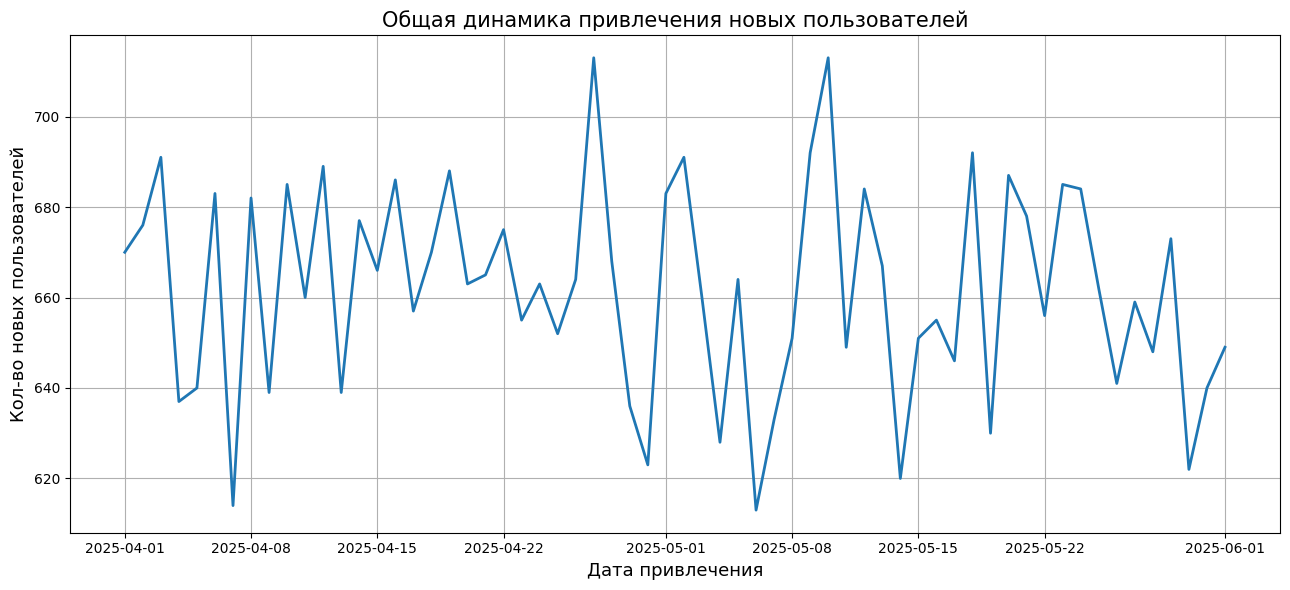

In [12]:
# Считаем дневную динамику новых пользователей по всем данным
daily_dynamics = df_hist.groupby('first_dt')['user_id'].nunique().reset_index()

# Строим график
plt.figure(figsize=(13, 6))

sns.lineplot(data=daily_dynamics, x='first_dt', y='user_id', linewidth=2)

plt.title('Общая динамика привлечения новых пользователей', fontsize=15)
plt.xlabel('Дата привлечения', fontsize=13)
plt.ylabel('Кол-во новых пользователей', fontsize=13)

plt.grid(.4)
plt.tight_layout()

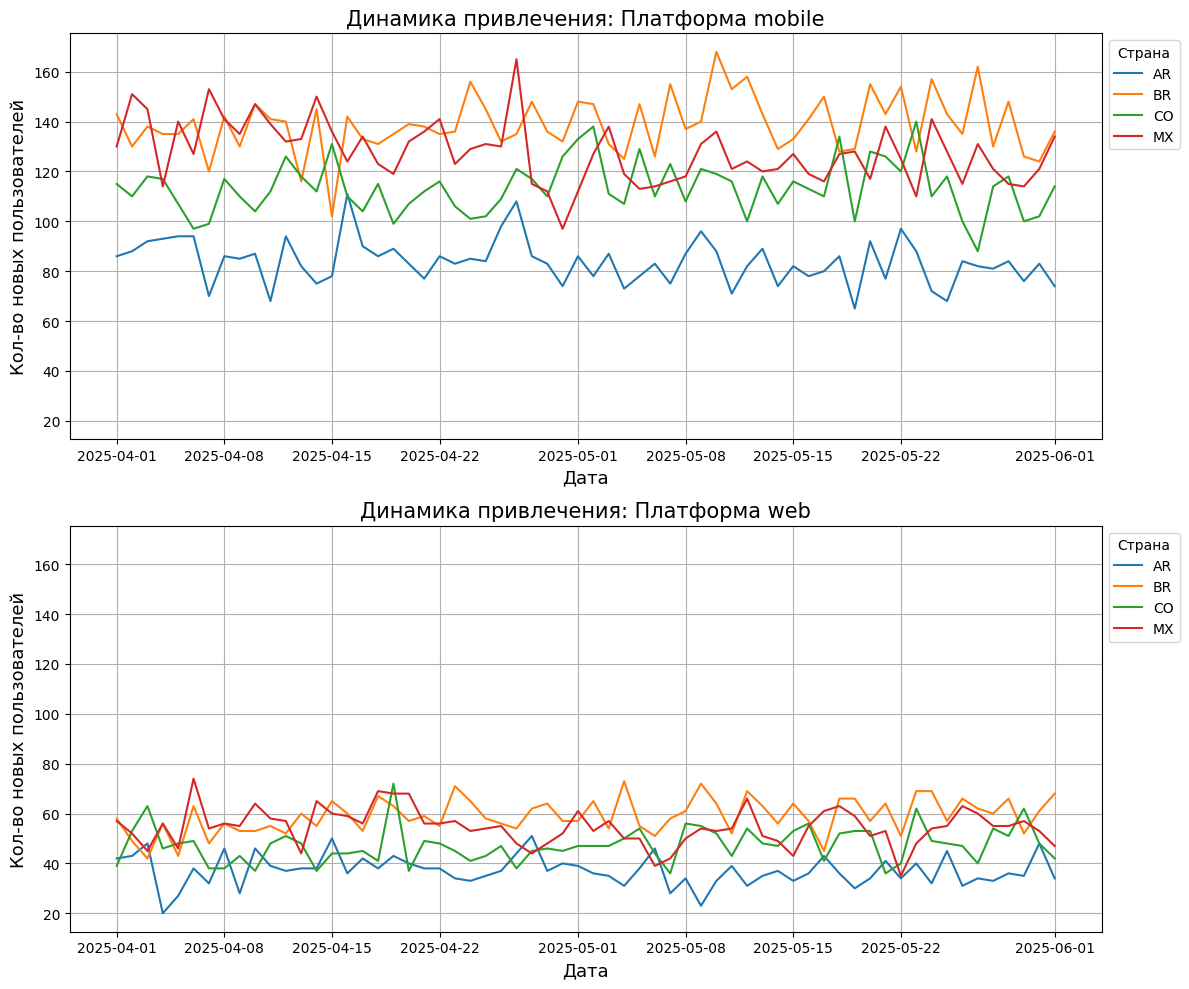

In [13]:
# Считаем кол-во пользователей по дням в разрезе платформ и стран
platform_country_dynamics = df_hist.groupby(['first_dt', 'platform', 'country_code'])['user_id'].nunique().reset_index()

# Рисуем графики
fig, ax = plt.subplots(2, 1, figsize=(12, 10), sharey=True)

for i, platform in enumerate(df_hist['platform'].unique()):
    sns.lineplot(
        ax=ax[i],
        data=platform_country_dynamics[platform_country_dynamics['platform'] == platform],
        x='first_dt', 
        y='user_id', 
        hue='country_code'
    )
    ax[i].set_title(f'Динамика привлечения: Платформа {platform}', fontsize=15)
    ax[i].set_xlabel('Дата', fontsize=13)
    ax[i].set_ylabel('Кол-во новых пользователей', fontsize=13)
    ax[i].legend(title='Страна', bbox_to_anchor=(1, 1), loc='upper left')
    ax[i].grid(.4)

plt.tight_layout()

**Выводы:**
- Количество новых пользователей за день колеблется примерно в значениях от 620 до 700. При этом по историческим данным нисходящего тренда не наблюдается.
- В мобильное приложение каждый день заходит в 2 с лишним раза больше новых пользователей, чем в десктопное.
- Соотношение привлеченных новых пользователей между странами сохраняется на обоих платформах. Из графиков видно, что в Бразилии (BR) привлекается больше всего новых пользователей, а в Аргентине (AR) - меньше всего. На втором месте Мексика (MX), а на третьем Колумбия (CO).

**Задача 2.2.** Анализ воронок событий.
- Построим классическую и пошаговую воронки;
- Охарактеризуем пользовательский путь в приложении и определим узкие места воронки. 


In [14]:
# Задаем последовательность этапов воронки
funnel_steps = ['install / open_web', 'registration', 'main_page', 'onboarding_complete', 'first_deposit', 'asset_purchase', 'second_deposit']

# Фильтруем датасет и считаем уникальных пользоваталей для каждого этапа
funnel_steps_df = df_hist[df_hist['event_name'].isin(funnel_steps)]
funnel_counts = funnel_steps_df.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)

# Создаем новый датафрейм для воронки
funnel_df = pd.DataFrame({
    'step': funnel_steps,
    'users': funnel_counts.values
})

# Считаем классическую и step-by-step конверсии
funnel_df['classic_conversion'] = funnel_df['users'] / funnel_df['users'].iloc[0] * 100
funnel_df['step_by_step'] = funnel_df['users'] / funnel_df['users'].shift(1) * 100

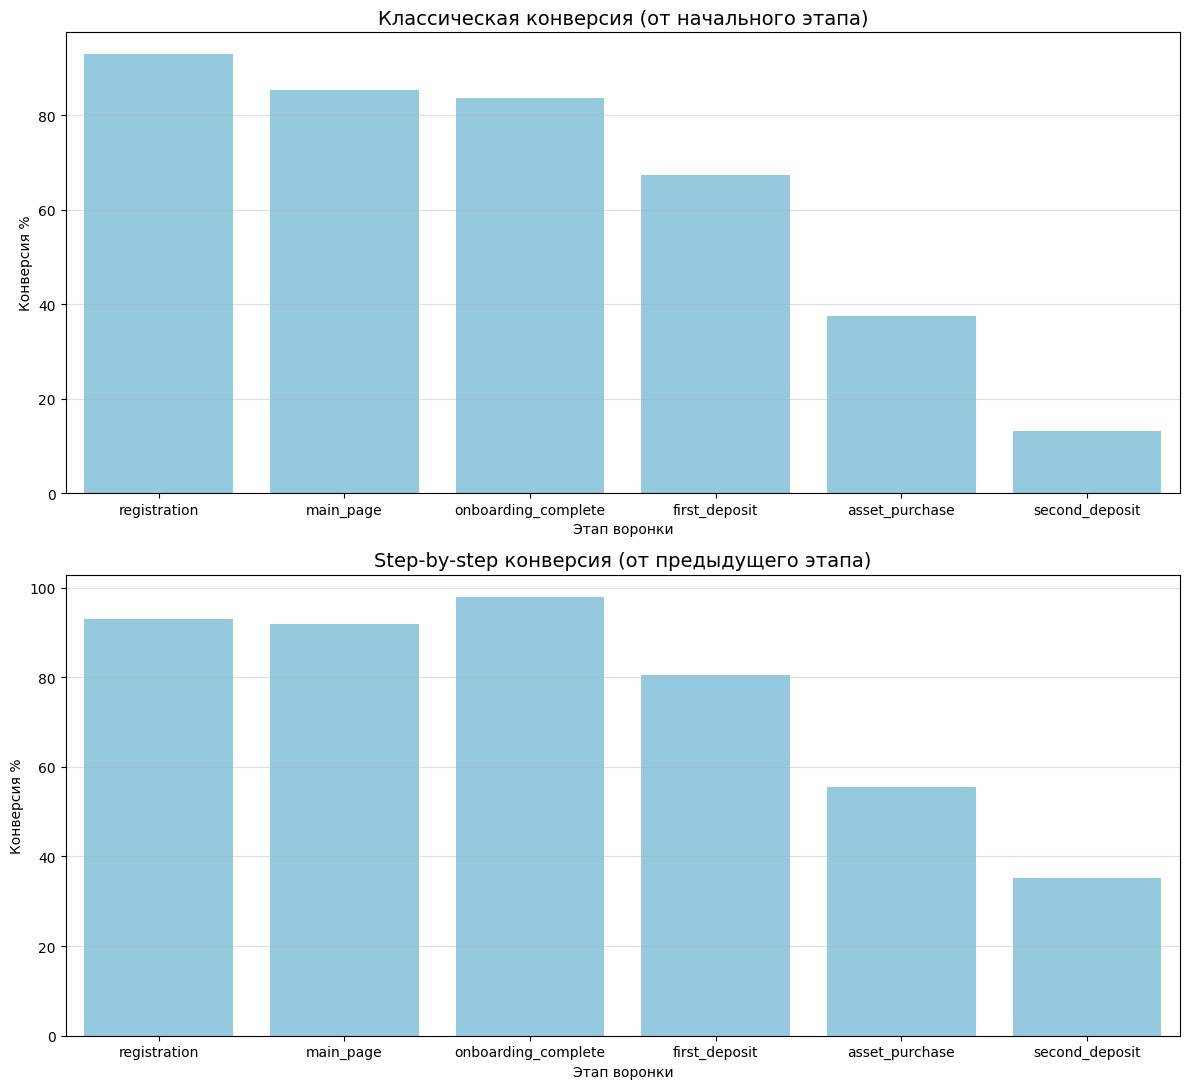

In [15]:
# Создаем два холста
fig, ax = plt.subplots(2, 1, figsize=(12, 11))

# Рисуем графики
sns.barplot(
    data=funnel_df[1:],
    x='step',
    y='classic_conversion',
    ax=ax[0],
    color='skyblue'
)
ax[0].grid(axis='y',alpha=.4)
ax[0].set_title('Классическая конверсия (от начального этапа)', fontsize=14)
ax[0].set_xlabel('Этап воронки')
ax[0].set_ylabel('Конверсия %')

sns.barplot(
    data=funnel_df[1:],
    x='step',
    y='step_by_step',
    ax=ax[1],
    color='skyblue'
)
ax[1].grid(axis='y',alpha=.4)
ax[1].set_title('Step-by-step конверсия (от предыдущего этапа)', fontsize=14)
ax[1].set_xlabel('Этап воронки')
ax[1].set_ylabel('Конверсия %')

plt.tight_layout()
plt.show()

**Выводы:**
- Первое серьезное снижение конверсии наблюдается на шаге `first_deposit` - первое пополнение брокерского счета. Значение конверсии в 80% кажется нормальным, если учесть, что дело касается денег пользователей.
- **Меньше 60% людей, совершивших первый депозит, покупают актив.** Это странно, потому что, как я понял, с брокерским счетом в этом приложении больше ничего сделать нельзя (*возможно есть какие-то причины пополнять брокерский счет и не расходовать его, но я о них не знаю*). Возможно люди боятся совершать покупку или просто хранят деньги на счету и ждут более хороших условий. Или, возможно, пользователи не могут разобраться, как это сделать. Есть вероятность, что все эти причины могут работать вместе. Нужно подумать, что с этим можно сделать.
- **После приобретения актива меньше 40% пользователей своершают второй депозит.** Вероятно, у многих пользователей первый опыт попкупки актива оказался неудачный. Или они попробовали и решили остановится по неизвестной нам причине. В обоих случаях можно попробовать как-то повлиять на пользователя в положительную сторону.

**Задача 2.3.** Влияние уровня риска актива на открытие второго депозита.
- Изучим, как уровень риска первого актива влияет на конверсию во второй депозит.  

In [16]:
# Проверим, есть ли пользователи с более чем одним вхождением поля risk_level
df_hist.groupby('user_id')['risk_level'].count().gt(1).sum()

0

У каждого пользователя не более одного значения `risk_level` - значит можно добавить новый столбец с этим признаком (если он есть) для каждого пользователя.

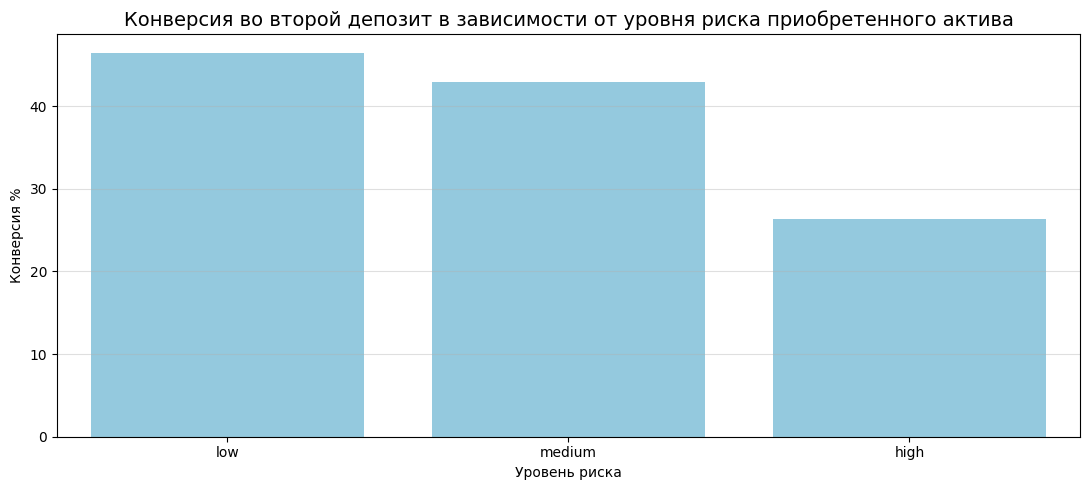

In [17]:
# Задаем последовательность этапов воронки
steps_risk = ['asset_purchase', 'second_deposit']

# Создаем столбец с признаком risk_level для каждого пользователя, у которого он есть.
df_hist['first_risk_level'] = df_hist.groupby('user_id')['risk_level'].transform('first')
# Удаляем строки с пропусками по новому столбцу
df_risk = df_hist.dropna(subset=['first_risk_level'])

# Фильтруем датасет и считаем уникальных пользоваталей для каждого этапа и уровня риска
steps_risk_df = df_risk[df_risk['event_name'].isin(steps_risk)]
funnel_risk_counts = steps_risk_df.groupby(['event_name', 'first_risk_level'])['user_id'].nunique().unstack().reindex(steps_risk).reset_index()

# Создаем словарь со значениями конверсии для каждого уровня риска
cr = {risk: (funnel_risk_counts[risk][1] / funnel_risk_counts[risk][0] * 100) for risk in df_risk['first_risk_level'].unique()}
# Создаем датафрейм и сортируем для визуализации
df_risk_cr = pd.DataFrame(cr.items(), columns=['risk_level', 'cr']).sort_values('cr', ascending=False)

# Рисуем график
plt.figure(figsize=(11,5))

sns.barplot(
    data=df_risk_cr,
    x='risk_level',
    y='cr',
    color='skyblue'
)

plt.grid(axis='y',alpha=.4)
plt.title('Конверсия во второй депозит в зависимости от уровня риска приобретенного актива', fontsize=14)
plt.xlabel('Уровень риска')
plt.ylabel('Конверсия %')

plt.tight_layout()

**Вывод:**
- На графике видно, что высокий уровень риска очень сильно понижает конверсию во второй депозит - примерно на 20 процентных пунктов в сравнении с низким уровнем риска. В то время как низкий и средний уровни риска сохраняют конверсию на уровне >40%.

**Задача 2.4.** Анализ ключевой метрики на исторических данных.
- На исторических данных рассчитаем значение ключевой метрики — средней суммы всех депозитов на одного пользователя. Учтем всех пользователей, которые взаимодействовали с сервисом. Это позволит зафиксировать базовый уровень монетизации.

In [18]:
# Фильтруем только события депозитов и считаем сумму на каждого юзера
user_dep_amount = df_hist[~df_hist['amount'].isna()].groupby('user_id')['amount'].sum()

# Общее количество уникальных пользователей
total_users_count = df_hist['user_id'].nunique()

# Средняя сумма всех депозитов на одного пользователя (включая неплатящих)
avg_dep = user_dep_amount.sum() / total_users_count

print(f'''
Средняя сумма всех депозитов на одного пользователя: {avg_dep:.2f}
Стандартное отклонение по суммарным депозитам: {df_hist.groupby('user_id')['amount'].sum().fillna(0).std():.2f}
''')


Средняя сумма всех депозитов на одного пользователя: 91.56
Стандартное отклонение по суммарным депозитам: 80.39



Стандартное отклонение (80.39) почти равно среднему значению (91.56). Это сведетельствует о том, что данные распределены не равномерно.

Скорее всего в данных большой хвост справа и очень много пользователей, которые не совершали депозит.

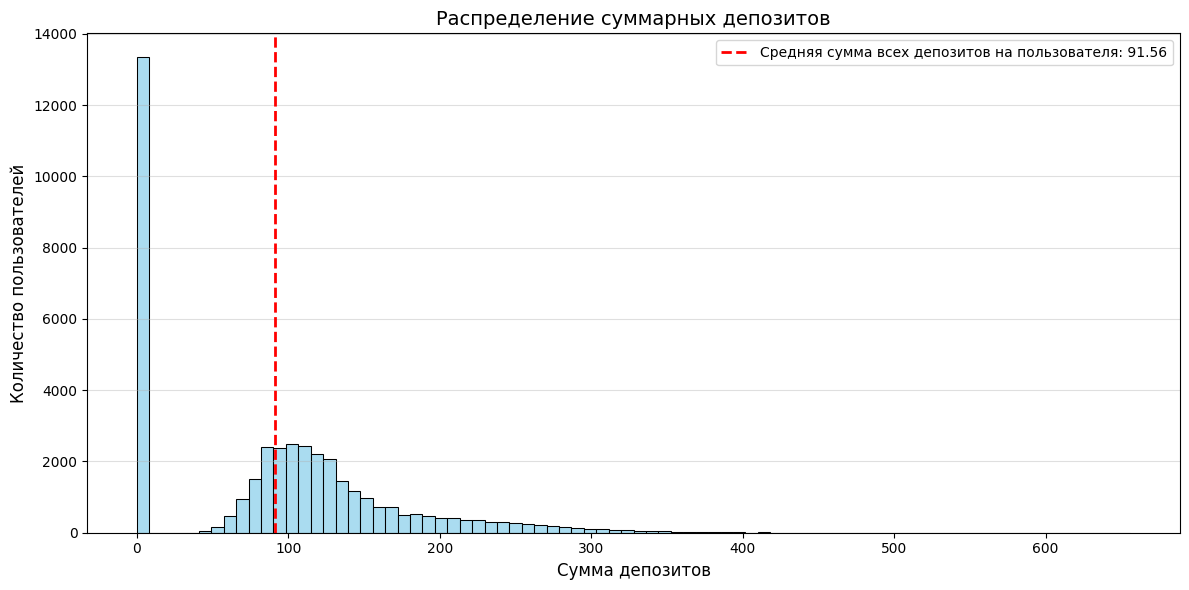

In [19]:
# Строим гистограмму
plt.figure(figsize=(12, 6))

sns.histplot(df_hist.groupby('user_id')['amount'].sum().fillna(0), bins=80, color='skyblue', edgecolor='black', alpha=0.7)

# Добавляем вертикальную красную прерывистую линию ARPU
plt.axvline(avg_dep, color='red', linestyle='--', linewidth=2, label=f'Средняя сумма всех депозитов на пользователя: {avg_dep:.2f}')

# Оформление заголовков
plt.title('Распределение суммарных депозитов', fontsize=14)
plt.xlabel('Сумма депозитов', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.legend()
plt.grid(axis='y',alpha=.4)

plt.tight_layout()

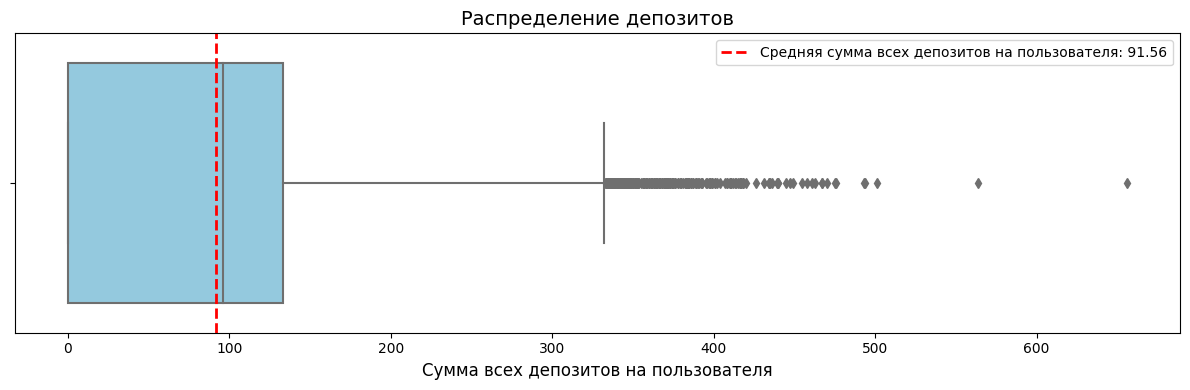

In [20]:
plt.figure(figsize=(12, 4))

# Рисуем горизонтальный boxplot
# orient='h' делает его горизонтальным автоматически при передаче в x
sns.boxplot(x=df_hist.groupby('user_id')['amount'].sum().fillna(0), color='skyblue', fliersize=5)

# Добавляем вертикальную красную прерывистую линию ARPU
plt.axvline(avg_dep, color='red', linestyle='--', linewidth=2, label=f'Средняя сумма всех депозитов на пользователя: {avg_dep:.2f}')

# Оформление
plt.title('Распределение депозитов', fontsize=14)
plt.xlabel('Сумма всех депозитов на пользователя', fontsize=12)
plt.legend()

plt.tight_layout()

**Вывод:**
- Как видно из графиков большинство людей не совершают депозитов. И при этом в этой метрике очень много выбросов.
- Боюсь, что обычный T-тест Уэлча может показать недостоверный результат.

---

## Часть 2

### 3. Исследование результатов А/В эксперимента

In [21]:
# Читаем файл
df_abt = pd.read_csv('pa_sollmafin_abt.csv', parse_dates=['first_ts', 'first_dt', 'event_ts'])

In [22]:
# Смотрим основую информацию о датасете
display(df_abt.head())
print('--'*30)
df_abt.info()

,user_id,country_code,platform,first_ts,first_dt,event_ts,event_name,ab_test,group,amount,asset,risk_level
0,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:51,install / open_web,onboarding_test,test,NaN,NaN,NaN
1,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-07 19:55:54,introduction,onboarding_test,test,NaN,NaN,NaN
2,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:09,registration,onboarding_test,test,NaN,NaN,NaN
3,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:18:13,main_page,onboarding_test,test,NaN,NaN,NaN
4,c430acb5-c6bf-43cf-8e2d-7ab9ce0d2c8a,BR,mobile,2025-06-07 19:55:51,2025-06-07,2025-06-08 06:33:40,onboarding_complete,onboarding_test,test,NaN,NaN,NaN


------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54805 entries, 0 to 54804
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   user_id       54805 non-null  object        
 1   country_code  54805 non-null  object        
 2   platform      54805 non-null  object        
 3   first_ts      54805 non-null  datetime64[ns]
 4   first_dt      54805 non-null  datetime64[ns]
 5   event_ts      54805 non-null  datetime64[ns]
 6   event_name    54805 non-null  object        
 7   ab_test       54805 non-null  object        
 8   group         54805 non-null  object        
 9   amount        7843 non-null   float64       
 10  asset         3750 non-null   object        
 11  risk_level    3750 non-null   object        
dtypes: datetime64[ns](3), float64(1), object(8)
memory usage: 5.0+ MB


In [23]:
# Количество дупликатов по сабсету user_id и event_ts
df_abt.duplicated(subset=['user_id', 'event_ts']).sum()

0

In [24]:
# Смотрим для каких событий заполняется столбец amount
df_abt[~df_abt['amount'].isna()]['event_name'].unique()

array(['first_deposit', 'second_deposit'], dtype=object)

In [25]:
# Смотрим для каких событий заполняется столбец asset
df_abt[~df_abt['asset'].isna()]['event_name'].unique()

array(['asset_purchase'], dtype=object)

In [26]:
# Смотрим для каких событий заполняется столбец risk_level
df_abt[~df_abt['risk_level'].isna()]['event_name'].unique()

array(['asset_purchase'], dtype=object)

In [27]:
# Проверим совпадают ли индексы строк с пропусками в столбцах asset и risk_level
df_abt['asset'].isna().index.to_list() == df_abt['risk_level'].isna().index.to_list()

True

In [28]:
# Проверим уникальные значения в столбцах с типом данных object
object_columns = [col for col in df_abt.columns if df_abt[col].dtype == 'object']
for col in object_columns:
    if col != 'user_id':
        print(f'''
        --- Уникальные значения в {col} ---
        {df_abt[col].unique()}''')


        --- Уникальные значения в country_code ---
        ['BR' 'MX' 'CO' 'AR']

        --- Уникальные значения в platform ---
        ['mobile' 'web']

        --- Уникальные значения в event_name ---
        ['install / open_web' 'introduction' 'registration' 'main_page'
 'onboarding_complete' 'first_deposit' 'asset_purchase' 'second_deposit']

        --- Уникальные значения в ab_test ---
        ['onboarding_test']

        --- Уникальные значения в group ---
        ['test' 'control']

        --- Уникальные значения в asset ---
        [nan 'crypto' 'stock' 'option']

        --- Уникальные значения в risk_level ---
        [nan 'high' 'low' 'medium']


In [29]:
print(f'''
Датасет содержит информацию о пользователях, вперые посетивших продукт в период с {df_abt.first_ts.min().date()} по {df_abt.first_ts.max().date()}.

А так же информацию о событиях в период с {df_abt.event_ts.min().date()} по {df_abt.event_ts.max().date()}.
''')


Датасет содержит информацию о пользователях, вперые посетивших продукт в период с 2025-06-02 по 2025-06-15.

А так же информацию о событиях в период с 2025-06-02 по 2025-06-22.



**Выводы:**
- Датасет A/B-теста заполняется так же корректно, как и дастасет с историческими данными.
- В датасете присутствуют пользователи только из A/B-теста `onboarding_test`.
- Пропусков в дополнительных полях `ab_test` и `group` не обнаружно.
- Датасет содержит информацию о пользователях, вперые посетивших продукт в период с 2025-06-02 по 2025-06-15. А так же информацию о событиях в период с 2025-06-02 по 2025-06-22.

**Задача 3.1.** Анализ аудитории эксперимента. 
- Проверьте корректность распределения новых пользователей по группам А/В-эксперимента. 
- Постройте графики и сформулируйте промежуточный вывод. 

In [30]:
# Проверим есть ли пользователи, которые попали в обе группы
group_count = df_abt.groupby('user_id')['group'].nunique().reset_index()
group_count[group_count['group']>1]['user_id'].unique()

array([], dtype=object)

В датасете нет пользователей, которые попали бы в обе группы одновременно

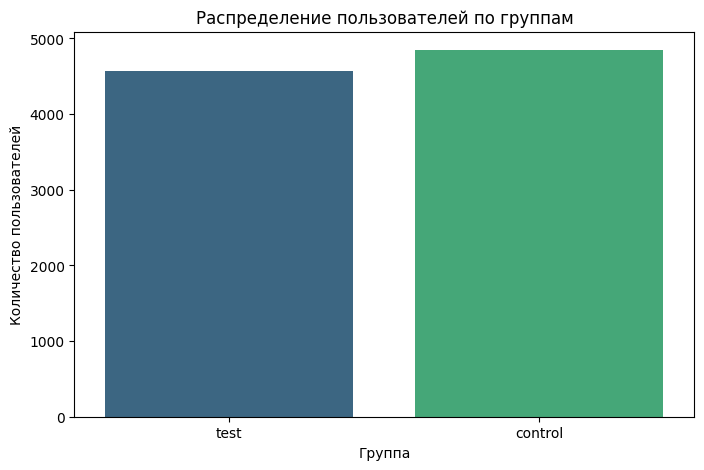


Количество пользователей в группах:
Тестовая - 4568 | Контрольная - 4847

Контрольная группа больше тестовой на 6.11%



In [31]:
# Оставляем только уникальных пользователей для анализа распределения
users_dist = df_abt[['user_id', 'group', 'platform', 'country_code']].drop_duplicates()

plt.figure(figsize=(8, 5))
sns.countplot(data=users_dist, x='group', palette='viridis')
plt.title('Распределение пользователей по группам')
plt.xlabel('Группа')
plt.ylabel('Количество пользователей')

plt.show()

print(f'''
Количество пользователей в группах:
Тестовая - {users_dist['group'].value_counts()[1]} | Контрольная - {users_dist['group'].value_counts()[0]}

Контрольная группа больше тестовой на {(users_dist['group'].value_counts()[0] / users_dist['group'].value_counts()[1] - 1):.2%}
''')

Контрольная группа получилась на 6.11% больше, чем тестовая.

Нужно посмотреть на кумулятивную сумму набора пользователей в группы. Возможно в какой-то момент распределение сломалось.

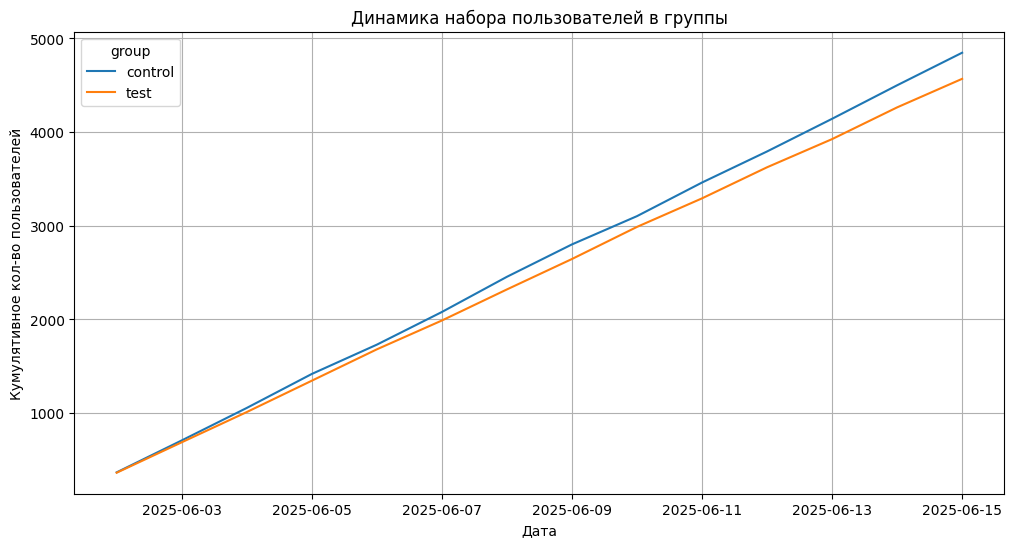

In [32]:
# Посчитаем кумулятивную сумму набора пользователей в группы
cumsum_users = (
    df_abt.groupby(['first_dt', 'group'])['user_id']
    .nunique()
    .groupby(level=1) # оставляем группировку только по группам
    .cumsum()
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=cumsum_users, x='first_dt', y='user_id', hue='group')

plt.grid(.4)
plt.title('Динамика набора пользователей в группы')
plt.xlabel('Дата')
plt.ylabel('Кумулятивное кол-во пользователей')
plt.show()

Как видно из графика набор в группы проходил стабильно. Просто в контрольную группу набиралось больше пользователей. Возможно дело в технических проблемах распределения.

Проверим как перекос в распределении по группам отразился на распределении по платформам и странам.

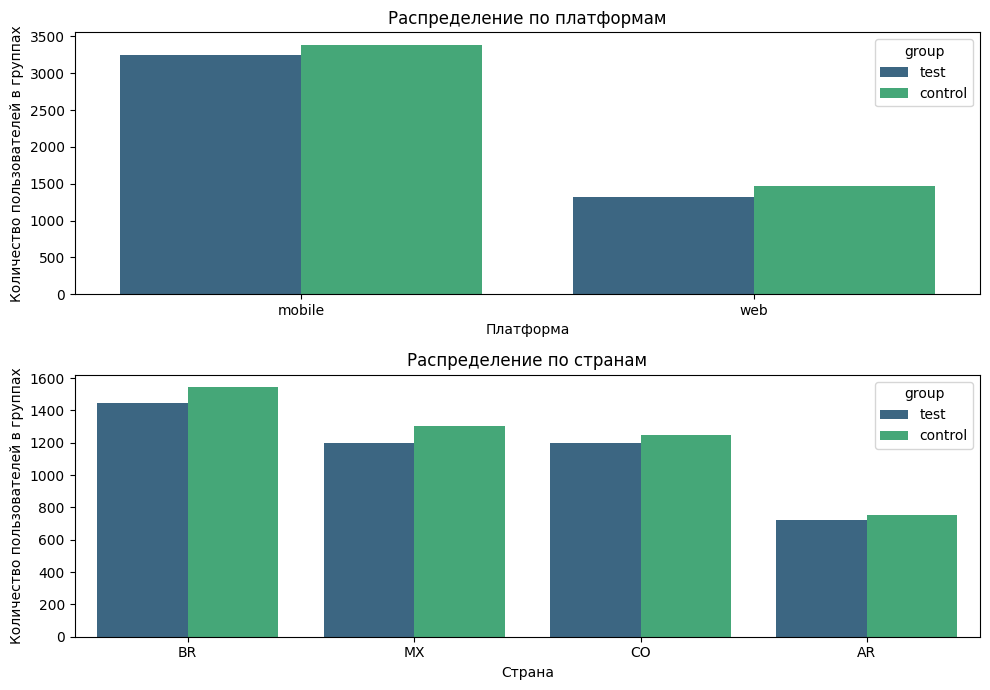

In [33]:
fig, ax = plt.subplots(2, 1, figsize=(10, 7))

# Распределение по платформам
sns.countplot(data=users_dist, x='platform', hue='group', ax=ax[0], palette='viridis')
ax[0].set_title('Распределение по платформам')
ax[0].set_xlabel('Платформа')
ax[0].set_ylabel('Количество пользователей в группах')

# Распределение по странам
sns.countplot(data=users_dist, x='country_code', hue='group', ax=ax[1], palette='viridis')
ax[1].set_title('Распределение по странам')
ax[1].set_xlabel('Страна')
ax[1].set_ylabel('Количество пользователей в группах')

plt.tight_layout()

Как видно из графика перекос в сторону контрольной группы наблюдается по всем категориальным признакам.

**Выводы:**
- Видимо в процессе распределения пользователей по группам есть технический недочет, из-за которого в контрольной группе оказалось больше пользователей.
- Набор в группы проходил стабильно без явных изменений с течением времени.
- В распределении по категориальным признакам так же стабильно есть перекос в сторону контрольной группы.
- Не уверен, насколько можно доверять результатам такого эксперимента.

**Задача 3.2.** Сравнение воронок событий.
- Сравним пользовательский путь новых пользователей в тестовой и контрольной группах.
- Построим классическую и последовательную воронки, выполним визуализацию и сделаем промежуточный вывод. 

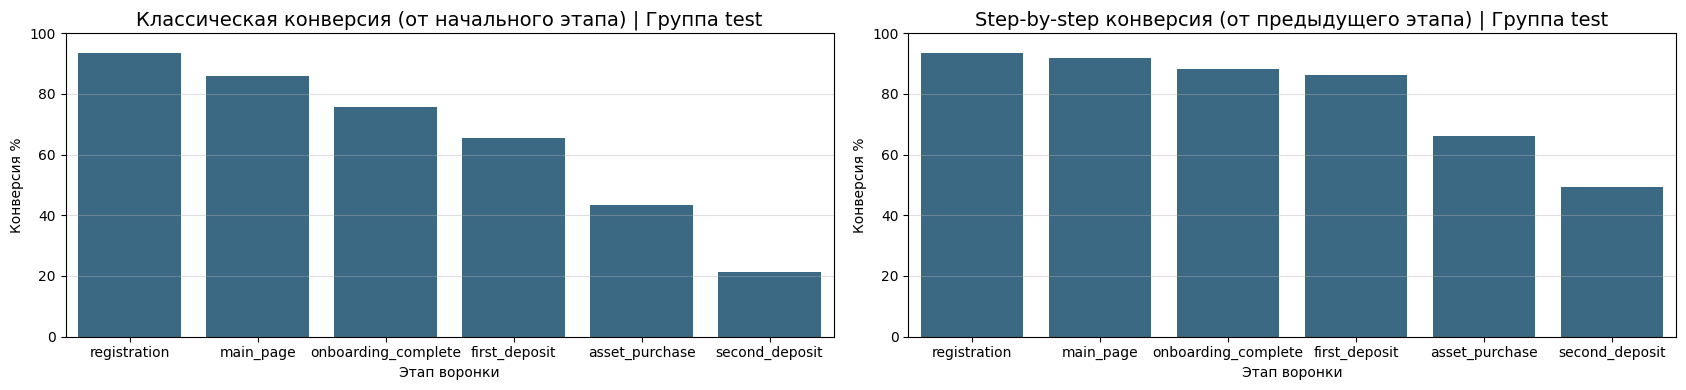

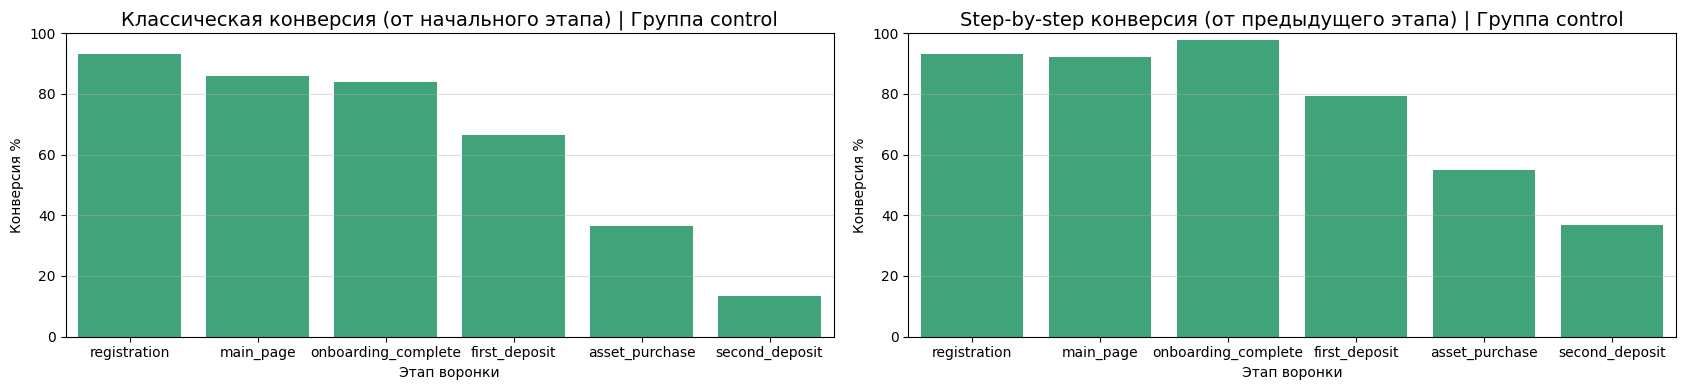

In [34]:
# Задаем последовательность этапов воронки
funnel_steps = ['install / open_web', 'registration', 'main_page', 'onboarding_complete', 'first_deposit', 'asset_purchase', 'second_deposit']
viridis_colors = plt.cm.viridis([0.35, 0.65]) # Чтобы палитра была похожа на предыдущие графики

for i, group in enumerate(df_abt['group'].unique()):
    current_color = viridis_colors[i]
# Фильтруем датасет и считаем уникальных пользоваталей для каждого этапа
    funnel_control_df = df_abt[(df_abt['event_name'].isin(funnel_steps)) &
                         (df_abt['group'] == group)]
    funnel_counts = funnel_control_df.groupby('event_name')['user_id'].nunique().reindex(funnel_steps)

# Создаем новый датафрейм для воронки
    funnel_df = pd.DataFrame({
        'step': funnel_steps,
        'users': funnel_counts.values
    })

# Считаем классическую и step-by-step конверсии
    funnel_df['classic_conversion'] = funnel_df['users'] / funnel_df['users'].iloc[0] * 100
    funnel_df['step_by_step'] = funnel_df['users'] / funnel_df['users'].shift(1) * 100

# Создаем два холста
    fig, ax = plt.subplots(1, 2, figsize=(17, 4))

# Рисуем графики
    sns.barplot(
        data=funnel_df[1:],
        x='step',
        y='classic_conversion',
        ax=ax[0],
        color=current_color
    )
    ax[0].grid(axis='y',alpha=.4)
    ax[0].set_ylim(0, 100)
    ax[0].set_title(f'Классическая конверсия (от начального этапа) | Группа {group}', fontsize=14)
    ax[0].set_xlabel('Этап воронки')
    ax[0].set_ylabel('Конверсия %')

    sns.barplot(
        data=funnel_df[1:],
        x='step',
        y='step_by_step',
        ax=ax[1],
        color=current_color
    )
    ax[1].grid(axis='y',alpha=.4)
    ax[1].set_ylim(0, 100)
    ax[1].set_title(f'Step-by-step конверсия (от предыдущего этапа) | Группа {group}', fontsize=14)
    ax[1].set_xlabel('Этап воронки')
    ax[1].set_ylabel('Конверсия %')

    plt.tight_layout()
    plt.show()

**Выводы:**
- На графиках заметно падение конверсии в завершение онбординга в тестовой группе. Это логично, ведь он стал более объемным и детализированным.
- Так же в тестовой группе можно отметить увеличение step-by-step конверсии в первый депозит и последующие после него шаги. Хотя классическая конверсия показывает примерно одинаковый показатель перехода в первый депозит, но в дальнейших шагах остается больше пользователей именно в тестовой группе.

**Задача 3.3.** Влияние новой фичи на конверсию во второй депозит с учётом уровня риска купленного актива.
- Проанализируем, как категория риска купленного актива влияет на вероятность открытия второго депозита в тестовой и контрольной группах. 
- Сравним результаты и оценим, есть ли статистически значимая разница между группами. 

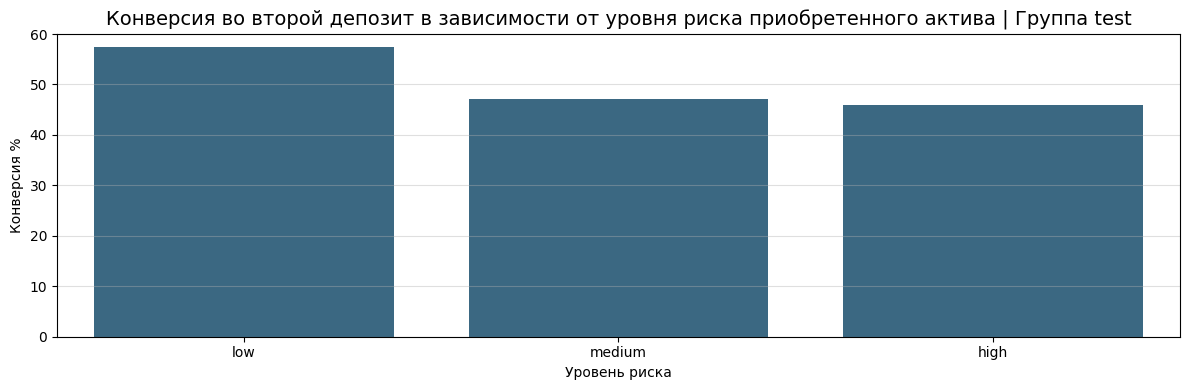

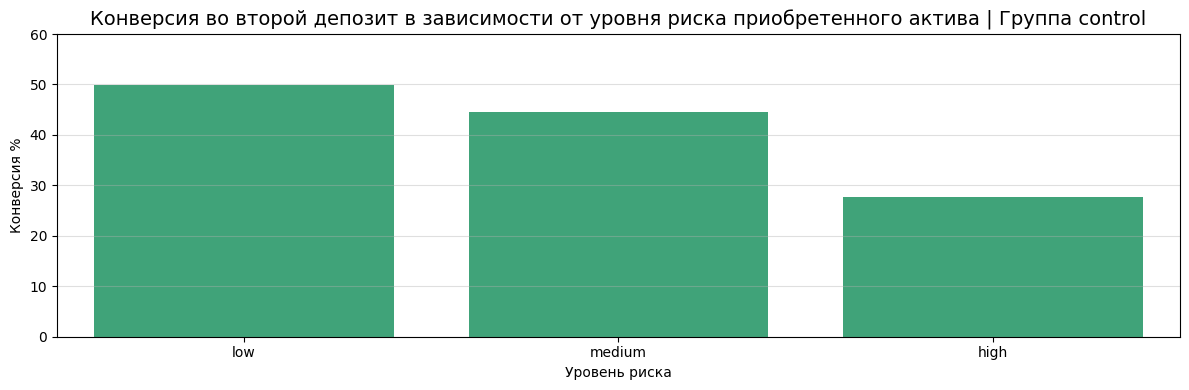

In [35]:
# Задаем последовательность этапов воронки
steps_risk = ['asset_purchase', 'second_deposit']
viridis_colors = plt.cm.viridis([0.35, 0.65])

# Создаем столбец с признаком risk_level для каждого пользователя, у которого он есть.
df_abt['first_risk_level'] = df_abt.groupby('user_id')['risk_level'].transform('first')
# Удаляем строки с пропусками по новому столбцу
df_risk = df_abt.dropna(subset=['first_risk_level'])

for i, group in enumerate(df_abt['group'].unique()):
    current_color = viridis_colors[i]
# Фильтруем датасет и считаем уникальных пользоваталей для каждого этапа и уровня риска
    steps_risk_df = df_risk[(df_risk['event_name'].isin(steps_risk)) &
                            (df_risk['group'] == group)]
    funnel_risk_counts = steps_risk_df.groupby(['event_name', 'first_risk_level'])['user_id'].nunique().unstack().reindex(steps_risk).reset_index()

# Создаем словарь со значениями конверсии для каждого уровня риска
    cr = {risk: (funnel_risk_counts[risk][1] / funnel_risk_counts[risk][0] * 100) for risk in df_risk['first_risk_level'].unique()}
# Создаем датафрейм и сортируем для визуализации
    df_risk_cr = pd.DataFrame(cr.items(), columns=['risk_level', 'cr']).sort_values('cr', ascending=False)

# Рисуем график
    plt.figure(figsize=(12,4))

    sns.barplot(
        data=df_risk_cr,
        x='risk_level',
        y='cr',
        color=current_color
    )

    plt.grid(axis='y',alpha=.4)
    plt.ylim(0, 60)
    
    plt.title(f'Конверсия во второй депозит в зависимости от уровня риска приобретенного актива | Группа {group}', fontsize=14)
    plt.xlabel('Уровень риска')
    plt.ylabel('Конверсия %')

    plt.tight_layout()
    plt.show()

In [36]:
group_df = df_abt.groupby(['user_id', 'group', 'first_risk_level']).agg(
    asset_purchase = ('event_name', lambda x: x.isin(['asset_purchase']).any()),
    second_deposit = ('event_name', lambda x: x.isin(['second_deposit']).any())
)
cr_df = group_df.groupby(['group', 'first_risk_level']).agg(
    asset_purch_users = ('asset_purchase', 'sum'),
    second_dep_users = ('second_deposit', 'sum')
).reset_index()

cr_df

,group,first_risk_level,asset_purch_users,second_dep_users
0,control,high,893,247
1,control,low,285,142
2,control,medium,595,265
3,test,high,737,339
4,test,low,496,285
5,test,medium,744,350


Гипотезы:
- **H0**: конверсия во второй депозит для разных уровней риска не отличается в тестовой и контрольной группе.
- **H1**: конверсия во второй депозит для разных уровней риска имеет статистически значимые различия в тестовой и контрольной группе.

Уровень значимости возьмем с учетом поправки Бонферрони для множественный сравнений. Так как мы попарно сравниваем конверсию для трех уровней риска, то значение `alpha` должно быть равно `0.05/3`.

In [37]:
results = []

# Проходим циклом по уровням риска и сравниваем Тест и Контроль
for risk in cr_df['first_risk_level'].unique():
    subset = cr_df[cr_df['first_risk_level'] == risk]
    
    # Количество успехов
    successes = subset['second_dep_users'].values
    # Количество попыток
    nobs = subset['asset_purch_users'].values
    
    # Z-test
    stat, p_value = proportions_ztest(successes, nobs)
    
    results.append({
        'risk_level': risk,
        'CR_control': round(successes[0]/nobs[0], 3),
        'CR_test': round(successes[1]/nobs[1], 3),
        'p_value': round(p_value, 4),
        'alpha': 0.05/3 # поправка Бонферрони для трех итераций сравнений
    })

res_df = pd.DataFrame(results)
res_df

,risk_level,CR_control,CR_test,p_value,alpha
0,high,0.277,0.460,0.0000,0.016667
1,low,0.498,0.575,0.0391,0.016667
2,medium,0.445,0.470,0.3607,0.016667


p-value ниже alpha только при высоком уровне риска.

**Выводы:**
- В тестовой группе конверсия из приобретения актива во второй депозит больше по всем видам уровня риска этого актива.
- При этом статистически значимые изменения в конверсии наблюдаются только для высокого уровня риска.
- Так же можно отметить, что конверсия для среднего и высокого риска в тестовой группе почти сравнялись, в то время как в контрольной группе разница между ними остается на уровне исторических данных. 

**Задача 3.4.** Анализ метрик А/В-эксперимента. Проанализируем такие метрики:
- Ключевая метрика — средняя сумма всех депозитов на одного пользователя (включая тех, кто установил приложение или открыл веб-версию).
- Барьерная метрика — конверсия из регистрации в первый депозит.
- Вспомогательная метрика 1 — конверсия из первого депозита во второй.
- Вспомогательная метрика 2 — средняя сумма всех депозитов на пользователя, который открыл хотя бы один депозит.

Для каждой метрики выведем: 
- значения в контрольной и тестовой группах, 
- абсолютные и относительные изменения значений в тестовой группе по сравнению с контрольной.

После этого проверим статистическую значимость различий метрик между группами эксперимента. 

Для ключевой метрики также изучим:
- накопленную динамику изменения по дням эксперимента для каждой группы, 
- стабильность p-value во время эксперимента.

In [38]:
# Подготавливаем данные на уровне пользователя
user_metrics = df_abt.groupby(['user_id', 'group']).agg(
    is_registered=('event_name', lambda x: x.isin(['registration']).any()), # .any(), чтобы вернуть True,
    first_deposit=('event_name', lambda x: x.isin(['first_deposit']).any()), # если у юзера было хотя бы одно совпадающее значение в столбце event_name
    second_deposit=('event_name', lambda x: x.isin(['second_deposit']).any()),
    total_deposits=('amount', 'sum')
).reset_index()

# Считаем sub-метрики с группировкой по группам
metrics_per_group = user_metrics.groupby('group').agg(
    total_users=('user_id', 'count'),
    registered_users=('is_registered', 'sum'),
    first_dep_users=('first_deposit', 'sum'),
    second_dep_users=('second_deposit', 'sum'),
    sum_all_deposits=('total_deposits', 'sum')
)

# Считаем нужные метрики
# Средняя сумма депозитов на всех пользователей
metrics_per_group['avg_dep_per_user'] = metrics_per_group['sum_all_deposits'] / metrics_per_group['total_users']

# Конверсия из регистрации в первый депозит
metrics_per_group['cr_reg_1dep'] = (metrics_per_group['first_dep_users'] / metrics_per_group['registered_users']) * 100

# Конверсия из первого депозита по второй
metrics_per_group['cr_1dep_2dep'] = (metrics_per_group['second_dep_users'] / metrics_per_group['first_dep_users']) * 100

# Средняя сумма депозитов на платящих пользователей
metrics_per_group['avg_dep_per_paying_user'] = metrics_per_group['sum_all_deposits'] / metrics_per_group['first_dep_users']

# Расчет изменений (test vs control)
results = metrics_per_group[['avg_dep_per_user', 'cr_reg_1dep', 'cr_1dep_2dep', 'avg_dep_per_paying_user']].T # .T, чтобы строки стали столбцами

results['abs_diff'] = results['test'] - results['control']
results['rel_diff_%'] = (results['test'] / results['control'] - 1) * 100

results.round(2)

group,control,test,abs_diff,rel_diff_%
avg_dep_per_user,90.24,92.46,2.22,2.46
cr_reg_1dep,71.54,70.04,-1.51,-2.11
cr_1dep_2dep,20.26,32.61,12.35,60.95
avg_dep_per_paying_user,135.50,141.40,5.90,4.35


В тестовой группе уменьшилась только конверсия из регистрации в первый депозит. Прохождение усложненного онбординга стало для некоторых пользователей стало преградой.

Самый большой прирост наблюдается в конверсии из перового депозита во второй. Онбордин положительно повлиял на эту метрику.

Средняя сумма всех депозитов на любого пользователя и на платящего пользователя в тестовой группе увеличились на 2.46% и 4.35% соответственно.

- Перед началом тестов проверим равны ли стандартные отклонения для выборок ключевой метрики и второй вспомогательной.

In [39]:
control_key = user_metrics[user_metrics['group']=='control']['total_deposits'].std()
test_key = user_metrics[user_metrics['group'] == 'test']['total_deposits'].std()

paying_user_metrics = user_metrics[user_metrics['total_deposits'] != 0]
control_supp2 = paying_user_metrics[paying_user_metrics['group']=='control']['total_deposits'].std()
test_supp2 = paying_user_metrics[paying_user_metrics['group'] == 'test']['total_deposits'].std()

print(f'''Ключевая метрика: контроль - {control_key:.2f}, тест - {test_key:.2f}
Вспомогательная метрика 2: контроль - {control_supp2:.2f}, тест - {test_supp2:.2f}''')

Ключевая метрика: контроль - 79.87, тест - 136.21
Вспомогательная метрика 2: контроль - 58.70, тест - 146.47


Стандартные отклонения в данных имеют сильные различия между группами. Лучше использовать T-тест Уэлча.

**Ключевая метрика**

Гипотезы:
- **H0**: выборочные средние ключевой метрики между группами равны.
- **H1**: выборочные средние между группами не равны.

Уровень статистической значимости alpha = 0.05

In [40]:
# p_value ключевой метрики
control = user_metrics[user_metrics['group']=='control']['total_deposits']
test = user_metrics[user_metrics['group'] == 'test']['total_deposits']

t_stat_key, p_val_key = ttest_ind(control, test, equal_var=False)

print(f'''
Уровень значимости: 0.05\n
P-value T-тест Уэлча ключевой метрики: {p_val_key} (двусторонняя гипотеза)
''')


Уровень значимости: 0.05

P-value T-тест Уэлча ключевой метрики: 0.33829488891764226 (двусторонняя гипотеза)



P-value > Aplha

Тест не показал статистически значимых различий в ключевой метрике между группами.

---
**Барьерная метрика**

Гипотезы:
- **H0**: конверсии из регистрации в первый депозит между группами равны.
- **H1**: конверсии между группами не равны.

Уровень статистической значимости alpha = 0.05

In [41]:
# p_value барьерной метрики
z_stat_barr, p_val_barr = proportions_ztest(
    metrics_per_group['first_dep_users'].to_list(),
    metrics_per_group['registered_users'].to_list()
)

print(f'''
Уровень значимости: 0.05\n
P-value Z-тест пропорций барьерной метрики: {p_val_barr} (двусторонняя гипотеза)
''')


Уровень значимости: 0.05

P-value Z-тест пропорций барьерной метрики: 0.12054344809112846 (двусторонняя гипотеза)



P-value > Aplha

Тест не показал статистически значимых различий в конверсии депозит между группами.

---
**Вспомогательная метрика 1**

Гипотезы:
- **H0**: конверсии из первого депозита во второй между группами равны.
- **H1**: конверсия из первого депозита во второй в тестовой группе больше.

Уровень статистической значимости alpha = 0.05

In [42]:
# p_value вспомогательной метрики 1
z_stat_supp1, p_val_supp1 = proportions_ztest(
    metrics_per_group['second_dep_users'].to_list(),
    metrics_per_group['first_dep_users'].to_list(),
    alternative = 'smaller'
)

print(f'''
Уровень значимости: 0.05\n
P-value Z-тест пропорций вспомогательной метрики 1: {p_val_supp1} (левосторонняя гипотеза)
''')


Уровень значимости: 0.05

P-value Z-тест пропорций вспомогательной метрики 1: 9.677942837686964e-29 (левосторонняя гипотеза)



P-value < Aplha

Тест показал, что конверсия из первого депозита во второй статистически больше в тестовой группе.

---
**Вспомогательная метрика 2**

Гипотезы:
- **H0**: выборочные средние вспомогательной метрики 2 между группами равны.
- **H1**: выборочное среднее вспомогательной метрики 2 в тестовой группе больше.

Уровень статистической значимости alpha = 0.05

In [43]:
# p_value вспомогательной метрики 2
paying_user_metrics = user_metrics[user_metrics['total_deposits'] != 0]
control = paying_user_metrics[paying_user_metrics['group']=='control']['total_deposits']
test = paying_user_metrics[paying_user_metrics['group'] == 'test']['total_deposits']

t_stat_supp2, p_val_supp2 = ttest_ind(control, test, equal_var=False, alternative='less')

print(f'''
Уровень значимости: 0.05\n
P-value T-тест Уэлча вспомогательной метрики 2: {p_val_supp2} (левосторонняя альтернативная гипотеза)
''')


Уровень значимости: 0.05

P-value T-тест Уэлча вспомогательной метрики 2: 0.020019343978859207 (левосторонняя альтернативная гипотеза)



P-value < Aplha

Тест показал, что средний суммарный депозит на платящего пользователя статистически значимо больше в тестовой группе.

Исследования статистической значимости метрик показывают, что значения суммарных депозитов для ключевой метрики не имеют статистически значимых изменений в тестовой группе по сравнению с контрольной. А вот для вспомогательной метрики 2 T-тест Уэлча показал, что значения суммарных депозитов для платящих пользователей статистически значимо отличаются между группами.

Z-тест пропорций вспомогательной метрики 1 показал стат. значимость различий в конверсии из первого депозита во второй между группами.

Z-тест пропорций барьерной метрики показал, что стат. значимого различия между конверсиями из регистрации в первый депозит между группами нет.

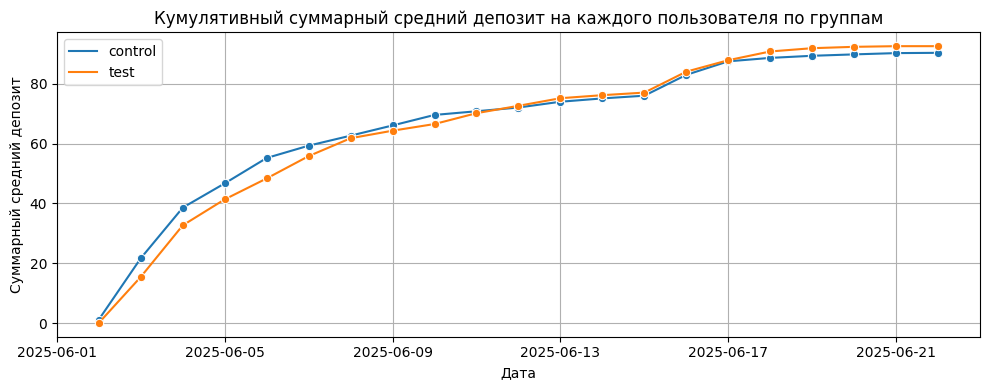

In [44]:
# Создаем столбец с датой события
df_abt['event_dt'] = df_abt['event_ts'].dt.date

# Пустой список для результатов
records = []

for current_date in sorted(df_abt['event_dt'].unique()):
    # 
    temp_df = df_abt[df_abt['event_dt']<=current_date]
    group_data = temp_df.groupby('group').agg(
        amount_sum = ('amount', 'sum'),
        users_count = ('user_id', 'nunique')
    ).reset_index()
    group_data['avg_dep'] = group_data['amount_sum'] / group_data['users_count']
    group_data['date'] = current_date
   
    records.append(group_data)

# Объединяем все результаты
avg_dep_df = pd.concat(records)

# Строим график
plt.figure(figsize=(10,4))

sns.lineplot(
    data=avg_dep_df,
    x='date',
    y='avg_dep',
    hue='group',
    marker='o'
)
    
plt.grid(.4)
plt.legend()

plt.xlabel('Дата')
plt.ylabel('Суммарный средний депозит')
plt.title('Кумулятивный суммарный средний депозит на каждого пользователя по группам')
plt.tight_layout()

На графике мы видим, что в разных группах ключевая метрика набиралась почти равномерно. Первую неделю контрольная группа была немного выше. Под конец тестовая группа вырвалась вперед, но не сильно.

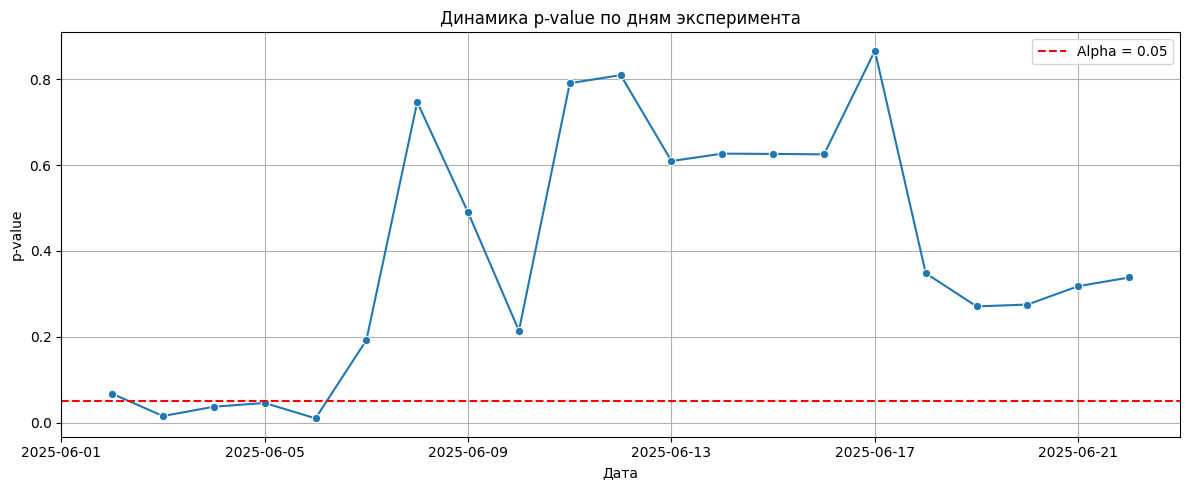

In [45]:
# Пустой список для p-value
pval_records = []

for current_date in sorted(df_abt['event_dt'].unique()):
    # Берем данные только до текущей даты включительно
    temp_df = df_abt[df_abt['event_dt']<=current_date]

    user_metric = temp_df.groupby(['user_id', 'group'])['amount'].sum().fillna(0).reset_index()
    
    control = user_metric[user_metric['group'] == 'control']['amount']
    test = user_metric[user_metric['group'] == 'test']['amount']

    p_value = ttest_ind(control, test, equal_var = False).pvalue
    
    pval_records.append({
        'date': current_date,
        'p_value': p_value
    })

pvalue_df = pd.DataFrame(pval_records)

# График P-value
plt.figure(figsize=(12, 5))

sns.lineplot(
    data=pvalue_df,
    x='date',
    y='p_value',
    marker='o'
)
plt.axhline(y=0.05, color='red', linestyle='--', label='Alpha = 0.05')

plt.grid(.4)
plt.title('Динамика p-value по дням эксперимента')
plt.xlabel('Дата')
plt.ylabel('p-value')
plt.legend()
plt.tight_layout()

График показывает, что в первую неделю p-value гуляло ниже уровня значимости, но затем сильно выросло и уже не опускалось до уровня 0.05. 

**Промежуточные выводы:**
- Стоит отметить, что распределение пользователей по группам не дало пропорции 50/50.
- Так же важно обратить внимание, что ключевая метрика имеет сильно скошенное влево распределение.
- При всем этом исследования показали, что стат. значимой разницы между группами по ключевой метрике нет. Т.е. средняя сумма депозитов на всех пользователей после внедрения изменений онбординга не имеет стат. значимых различий между группами.
- А вот для воспомогательной метрики 2 были обнаружены стат. значимые изменения. Т.е. средняя сумма депозитов на платящих пользователей значимо изменилась.
- Барьерная метрика не имеет значимых различий между группами. Т.е. конверсия из регистрации в первый депозит изменилась не значимо.
- Вспомогательная метрика 1 (конверсия из первого депозита во второй) показала стат. значимые различия между группами.

---

### 4. Анализ изменений суммы депозитов на платящего пользователя

Новая фича могла повлиять на поведение пользователей.
- Пользователи, которые раньше вносили небольшие суммы, могли стать более осторожными, сократить свои вложения или совсем перестать платить. Это отразится в снижении 25-го перцентиля суммы депозитов в тестовой группе.
- Пользователи, которые склонны к более крупным инвестициям, могли сильнее вовлечься в продукт и начать вносить больше средств. Это отразится в росте 75-го перцентиля.

Используя бутстрап, сравним разницы перцентилей (25, 50, 75) суммы всех депозитов на платящего пользователя в контрольной и тестовой группах:
- Построим доверительные интервалы для разницы между группами для каждого перцентиля.
- Интерпретируем изменения в контексте сформулированной выше гипотезы.
- Визуализируем результат бутстрап-теста. 

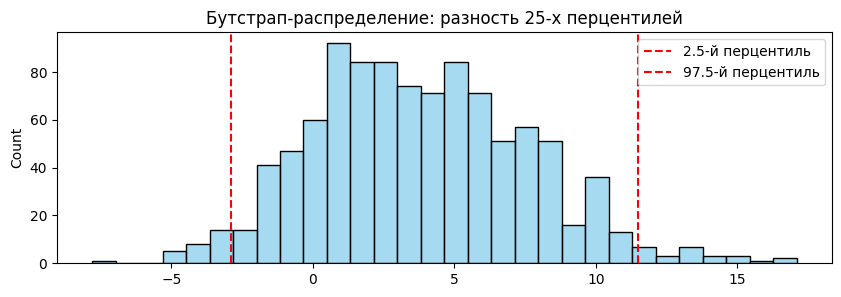

25-й перцентиль контрольной группы: 36.47
25-й перцентиль тестовой группы: 39.01
95%-й доверительный интервал разности 25-х перцентилей [-2.88, 11.50]



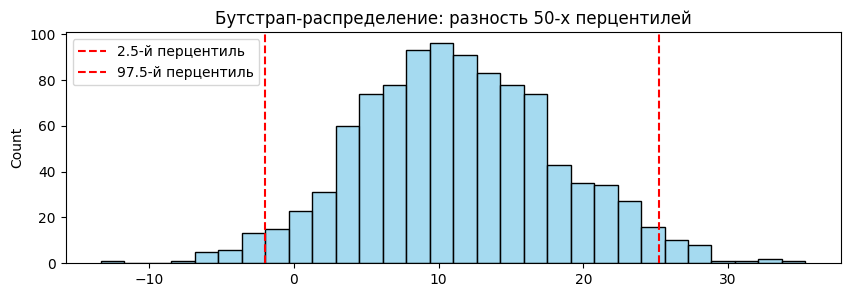

50-й перцентиль контрольной группы: 93.06
50-й перцентиль тестовой группы: 103.41
95%-й доверительный интервал разности 50-х перцентилей [-2.00, 25.20]



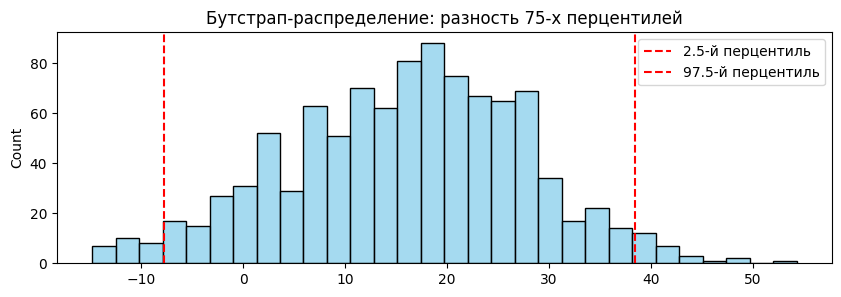

75-й перцентиль контрольной группы: 184.80
75-й перцентиль тестовой группы: 202.07
95%-й доверительный интервал разности 75-х перцентилей [-7.73, 38.45]



In [46]:
# Фиксируем сид для воспроизводимости
np.random.seed(42)

# Генерируем данные: контроль и тест по 1000 наблюдейний
# Средние значения метрики для групп берем из посчитаной ранее таблицы
control = np.random.exponential(scale=results['control'][-1], size=1000)
test = np.random.exponential(scale=results['test'][-1], size=1000)

n_iterations = 1000

for percentile in [25, 50, 75]:
    boot_diffs = []
    # Бутстрап-разница перцентилей между тестовой и контрольной группами
    for i in range(n_iterations):
        boot_control = np.random.choice(control, size=len(control), replace=True)
        boot_test = np.random.choice(test, size=len(test), replace=True)

        # Для расчёта перцентиля используем .percentile() из библиотеки numpy 
        control_p = np.percentile(boot_control, percentile)
        test_p = np.percentile(boot_test, percentile)

        # Находим разницу между значениями тестовой и контрольной групп
        boot_diffs.append(test_p - control_p)

    # Создаём массив разниц между перцентилями тестовой и контрольной групп
    boot_diffs = np.array(boot_diffs)

    # Доверительный интервал разницы между 95-ми перцентилями (перцентильный метод)
    diff_ci = np.percentile(boot_diffs, [2.5, 97.5])

    #Гистограмма
    plt.figure(figsize=(10, 3))

    sns.histplot(boot_diffs, bins=30, color='skyblue', edgecolor='black')
    plt.axvline(diff_ci[0], color='red', linestyle='--', label='2.5-й перцентиль')
    plt.axvline(diff_ci[1], color='red', linestyle='--', label='97.5-й перцентиль')
    plt.title(f'Бутстрап-распределение: разность {percentile}-х перцентилей')
    plt.legend()
    plt.show()

    # Вывод доверительного интервала
    print(f"{percentile}-й перцентиль контрольной группы: {np.percentile(control, percentile):.2f}")
    print(f"{percentile}-й перцентиль тестовой группы: {np.percentile(test, percentile):.2f}")
    print(f"95%-й доверительный интервал разности {percentile}-х перцентилей [{diff_ci[0]:.2f}, {diff_ci[1]:.2f}]\n")

Бутстрап-распределение показывает, что первый, второй и третий квартили в тестовой группе выше, чем в контрольной.

При построении 95%-го доверительного интервала для разницы первого, второго и третьего квартилей между контрольной и тестовой группой выяснилось, что во всех случаях разброс лежит по обе стороны от нуля. Хоть и основная масса значений лежит выше нуля, но все же доверительный интервал заходит в отрицательную зону. Это может говорить о том, что квартили в тестовой группе могли измениться в негативную сторону, но при этом выбросы стали больше.

---

### 5. Выводы

**Выводы:**
- Эксперимент был проведен с нарушением распределения пользователей по группам.
- Новый онбординг не показал значимых изменений в ключевой метрике - средний суммарный депозит на всех пользователей.
- Так же новая фича не показала значимых изменений в барьерной метрике, что хорошо.
- В следствии внедрения более детализированного онбординга значимо выросла конверсия из первого депозита во второй (на 61%). А так же немного (но тоже значимо) подрос средний депозит на платящего пользоателя (на 4%).

Хоть ключевая метрика и не показала значимого роста, конверсия во второй депозит значительно возросла. Это значит, что пользователи теперь реже бросают продукт после первой покупки актива. Возможно это даже лучше в долгосроке для LTV, но по этим данным такого точно сказать нельзя.

Конверсия в первый депозит действительно снизилась, но не статистически значимо.

Так же немного, но значимо, выросла средняя сумма депозитов на платящих пользователей.

Если цель была именно в снижении оттока пользователей после первого купленного актива, то фича сработала отлично. Но стоит помнить, что ключевая метрика не имела стат. значимых изменений.